# Build it yourself — the conditional discrepancy-optimized LHS

A clean, self-contained walkthrough of how the **LHS + simulated annealing** sampler (used in
`experiment03_hfo2_doe_design.ipynb`) is built from scratch. The centerpiece is **my own solution**
to the optimizer loop, with the convergence curve that motivates simulated annealing.

The idea in one line: start from a Latin Hypercube and repeatedly **swap two values within a
column** (which keeps it a valid LHS), keeping the swap only if it lowers the **centered-L2
discrepancy** of the combined design — so a fixed batch + a new batch get arranged to fill space.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
import warnings; warnings.filterwarnings('ignore')

## The building blocks

Three helpers, each a single idea:

* **`cum_disc(P)`** — the objective: centered-L2 discrepancy of a point set `P` (lower = more
  uniform). When we score `np.vstack([b1, b2])` we are judging the *combined* design.
* **`start_b2(...)`** — a discrepancy-optimized Latin Hypercube (scipy's `random-cd`), the starting
  design the search then refines. The Latin property = exactly one point per stratum on every axis.
* **`swap_in_column(...)`** — the move: exchange two rows within one column. The column's set of
  values is unchanged, so the design stays a valid LHS; only the cross-column pairing moves.

In [24]:
def cum_disc(P):
    return qmc.discrepancy(P)

def start_b2(n2, dim, seed):
    return qmc.LatinHypercube(d=dim, optimization="random-cd", seed=seed).random(n2)

def swap_in_column(b2, col, a, b):
    b2[[a, b], col] = b2[[b, a], col]

# quick checks
_t = start_b2(8, 3, 0)
_bins = np.floor(_t * 8).astype(int)
assert all(sorted(_bins[:, k].tolist()) == list(range(8)) for k in range(3)), "start is not Latin"
_before = sorted(_t[:, 1].tolist()); swap_in_column(_t, 1, 0, 5)
assert sorted(_t[:, 1].tolist()) == _before, "swap changed the column's value set"
print("helpers OK — Latin start + value-preserving swap")

helpers OK — Latin start + value-preserving swap


## My solution — the accept/revert loop (Tasks 4 & 5)

Greedy hill-climbing: propose a swap, recompute the cumulative discrepancy, **keep it if it
dropped, otherwise revert**. I also record the running-best each iteration so I can plot the
convergence curve.

Tasks 4-5 PASS - cumulative discrepancy 0.12796 -> 0.05720

You have rebuilt conditional_olhs_b2. Change Task 1 to discrepancy(b2) alone
and you have rebuilt scipy's standalone optimization='random-cd'.


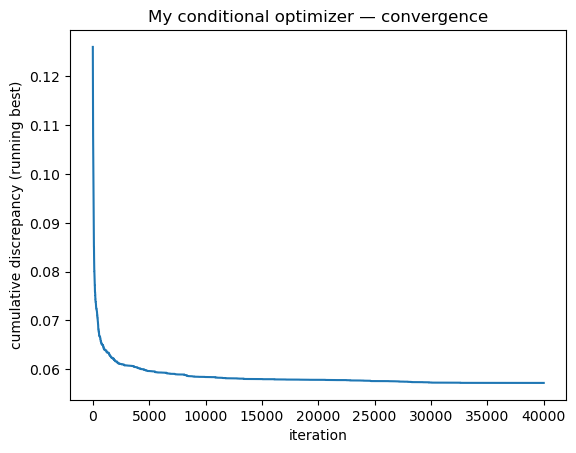

In [25]:
import pandas as pd
# --- Tasks 4 & 5: accept/revert rule inside the loop -------------------------
def my_conditional_olhs(b1, n2, dim, seed, n_iter=8000):
    rng = np.random.default_rng(seed)
    b2 = start_b2(n2, dim, seed)
    all_toagether = np.vstack([b1, b2])
    best_value = cum_disc(all_toagether)
    iter_list = []
    value_list = []
    for i in range(n_iter):
        iter_list.append(i)
        col = rng.integers(dim)
        a, b = rng.choice(n2, 2, replace=True)
        swap_in_column(b2, col, a, b)
        all_toagether_iter = np.vstack([b1, b2])
        best_value_iter = cum_disc(all_toagether_iter)
        if best_value_iter < best_value:
            best_value = best_value_iter
            value_list.append(best_value)
            continue
        else:
            value_list.append(best_value)
            swap_in_column(b2, col, a, b)
    iter_vs_value_series = pd.Series(value_list, iter_list)
    return b2, best_value, iter_vs_value_series

# final self-check: the optimizer must not INCREASE cumulative discrepancy
_b1 = qmc.LatinHypercube(d=10, optimization="random-cd", seed=7).random(20)
all_toagether_start = np.vstack([_b1, start_b2(20, 10, 7)])
_start = cum_disc(all_toagether_start)
_b2_opt, _final, iter_vs_value_series = my_conditional_olhs(_b1, 20, 10, 7, n_iter=40000)
plt.plot(iter_vs_value_series)
plt.xlabel("iteration"); plt.ylabel("cumulative discrepancy (running best)")
plt.title("My conditional optimizer — convergence")
assert _final <= _start + 1e-12
print(f"Tasks 4-5 PASS - cumulative discrepancy {_start:.5f} -> {_final:.5f}")
print("\nYou have rebuilt conditional_olhs_b2. Change Task 1 to discrepancy(b2) alone")
print("and you have rebuilt scipy's standalone optimization='random-cd'.")

**Reading the curve.** The running-best drops fast then **flattens** — greedy hill-climbing only
ever moves downhill, so once it reaches a local minimum every later swap is rejected and the curve
freezes. That plateau (visible even with `n_iter=40000`) is exactly what motivates the next step.

One small thing to note in my version: `rng.choice(n2, 2, replace=True)` can pick `a == b`, a
"swap" that does nothing — a few % of iterations are wasted no-ops. Using `replace=False` makes
every iteration a real move (it doesn't change the result, just efficiency).

## Visualizing the design as a heatmap — seeing the swaps and the greedy search

A direct way to *see* what the optimizer does is to draw the LHS design as a **heatmap**: rows =
runs, columns = factors, color = the unit value in [0, 1]. A single swap just exchanges two cells
within one column; greedy hill-climbing is many accepted swaps that reshuffle the columns until the
points fill space (discrepancy drops).

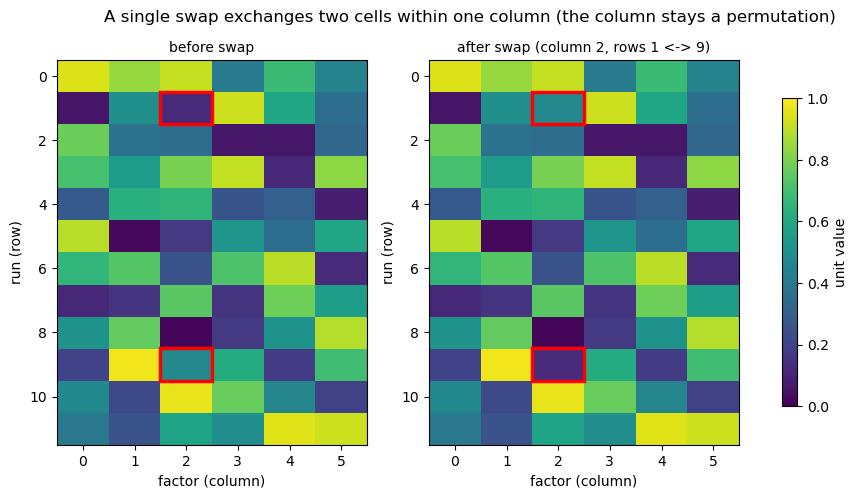

In [26]:
def show_lhs_heatmap(P, ax=None, title="", highlight=None):
    """Heatmap of an LHS design: rows = runs, cols = factors, color = unit value in [0, 1].
    `highlight` = list of (row, col) cells to outline (e.g. the pair a swap exchanges)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(P, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    ax.set_xlabel("factor (column)"); ax.set_ylabel("run (row)"); ax.set_title(title, fontsize=10)
    ax.set_xticks(range(P.shape[1]))
    if highlight:
        for r, c in highlight:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, ec="red", lw=2.5))
    return im

# (1) one swap: before vs after, with the two exchanged cells outlined
P = start_b2(12, 6, 0)
col, ra, rb = 2, 1, 9
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
show_lhs_heatmap(P, ax[0], "before swap", highlight=[(ra, col), (rb, col)])
Q = P.copy(); swap_in_column(Q, col, ra, rb)
im = show_lhs_heatmap(Q, ax[1], f"after swap (column {col}, rows {ra} <-> {rb})",
                      highlight=[(ra, col), (rb, col)])
fig.colorbar(im, ax=ax, label="unit value", shrink=0.8)
plt.suptitle("A single swap exchanges two cells within one column (the column stays a permutation)")
plt.show()

And the greedy search start → finish, now **conditioned on `_b1`** — the *same* 20-point, 5-D
fixed batch used in the greedy-vs-SA figure below. b2 starts from a plain LHS; the heatmap stacks
`_b1` (top, fixed, above the red line) over b2 (bottom), and only b2's rows reshuffle to lower the
**combined** discrepancy. Because it is the same `_b1` — same `n` and `d` — this curve now shares
the y-scale with the greedy-vs-SA plot.

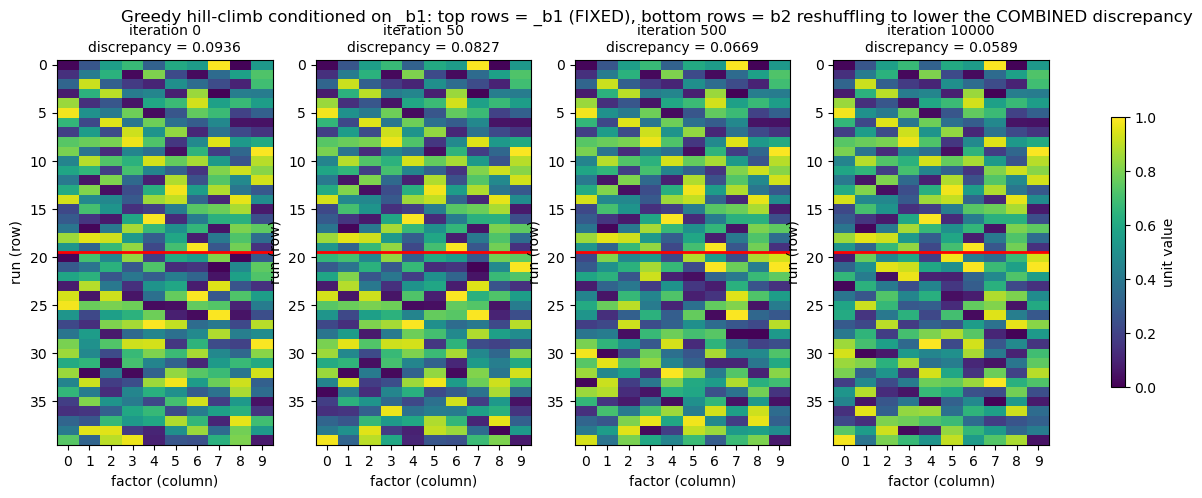

In [27]:
def greedy_snapshots(fixed, n2, seed, n_iter, snaps):
    """Greedy hill-climb of a NEW batch (n2 points) conditioned on `fixed`, minimizing the
    discrepancy of the combined [fixed; b2]. The new batch's dimensionality is TAKEN FROM `fixed`
    -- nothing is hard-coded, so the columns can never mismatch. b2 starts from a plain LHS.
    Returns full-design snapshots at `snaps` and the running-best discrepancy curve."""
    dim = fixed.shape[1]                                   # <-- derive dim from `fixed`
    rng = np.random.default_rng(seed)
    b2 = qmc.LatinHypercube(d=dim, seed=seed).random(n2)   # plain LHS start, dim matches `fixed`
    score = lambda: cum_disc(np.vstack([fixed, b2]))
    best = score(); shots = {0: np.vstack([fixed, b2])}; curve = [best]
    for i in range(1, n_iter + 1):
        c = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, c, a, b); cur = score()
        if cur < best:
            best = cur
        else:
            swap_in_column(b2, c, a, b)       # revert
        if i in snaps:
            shots[i] = np.vstack([fixed, b2])
        curve.append(best)
    return shots, np.array(curve)

snaps = [0, 50, 500, 10000]
shots, curve = greedy_snapshots(_b1, len(_b1), 7, 10000, snaps)   # n2 & dim both come from _b1
n_fixed = len(_b1)
fig, axes = plt.subplots(1, len(snaps), figsize=(4 * len(snaps), 5))
for ax, it in zip(axes, snaps):
    im = show_lhs_heatmap(shots[it], ax, f"iteration {it}\ndiscrepancy = {cum_disc(shots[it]):.4f}")
    ax.axhline(n_fixed - 0.5, color="red", lw=2)               # _b1 (top, fixed) | b2 (bottom, optimized)
fig.colorbar(im, ax=axes, label="unit value", shrink=0.7)
plt.suptitle("Greedy hill-climb conditioned on _b1: top rows = _b1 (FIXED), "
             "bottom rows = b2 reshuffling to lower the COMBINED discrepancy")
plt.show()

### Iteration vs discrepancy (greedy hill-climb)

The convergence curve for the **same** run as the heatmaps above — discrepancy (running best) vs
iteration. The red dots mark the four snapshot iterations, so you can read each heatmap against its
point on the curve. The fast drop then flat tail is the greedy plateau: once at a local minimum,
every further swap is rejected.

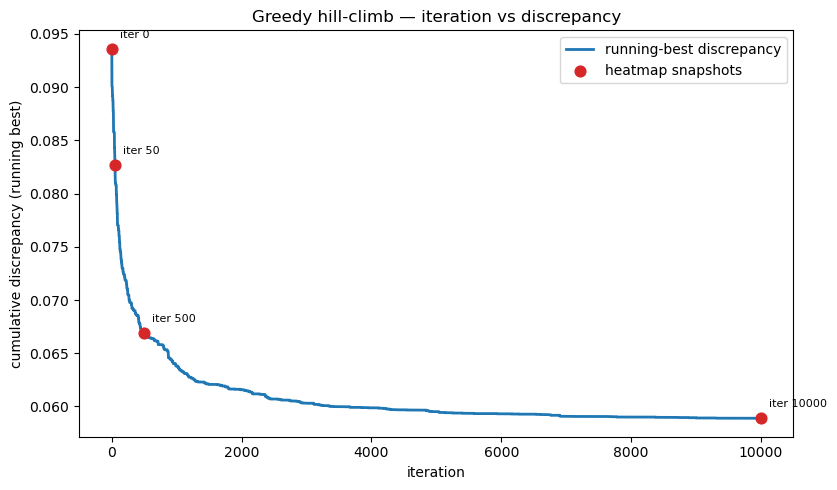

start 0.0936  ->  final 0.0589  (effectively converged — within 1% — by iter 5042; the rest is a flat plateau)


In [28]:
plt.figure(figsize=(8.5, 5))
plt.plot(curve, color="#1f77b4", lw=2, label="running-best discrepancy")
plt.scatter(snaps, curve[snaps], color="#d62728", zorder=5, s=60, label="heatmap snapshots")
for it in snaps:
    plt.annotate(f"iter {it}", (it, curve[it]), textcoords="offset points", xytext=(6, 8), fontsize=8)
plt.xlabel("iteration"); plt.ylabel("cumulative discrepancy (running best)")
plt.title("Greedy hill-climb — iteration vs discrepancy")
plt.legend(); plt.tight_layout(); plt.show()
eff = int(np.argmax(curve <= curve[-1] * 1.01))   # first iter within 1% of the final value
print(f"start {curve[0]:.4f}  ->  final {curve[-1]:.4f}  "
      f"(effectively converged — within 1% — by iter {eff}; the rest is a flat plateau)")

## Next step — simulated annealing (escaping the plateau)

Same move, but the accept rule sometimes keeps a *worse* swap with probability `exp(-Δ/T)`, with a
temperature `T` that cools over time. High `T` early = explore out of basins; `T → 0` late = greedy
finish. We track a separate best-ever design because the search is now allowed to wander uphill.

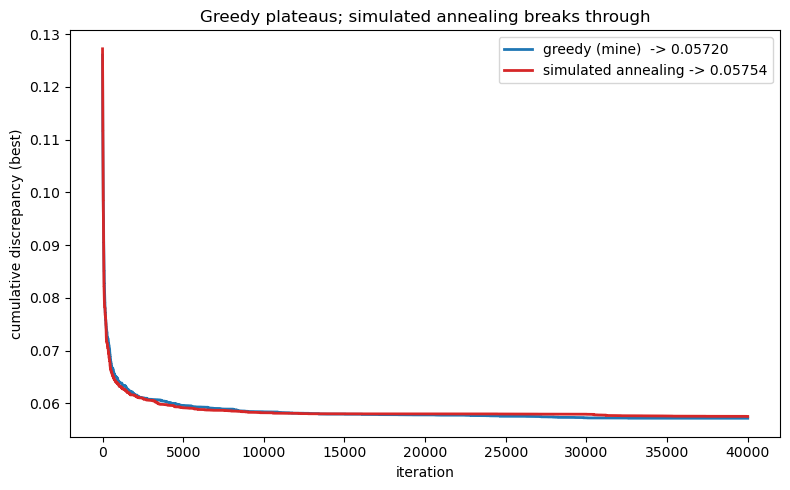

greedy 0.05720  vs  annealed 0.05754  (-0.6%)


In [32]:
def my_annealed_olhs(b1, n2, seed, n_iter=8000, T_end=1e-3):
    """Simulated-annealing version of the conditional optimizer. Dimensionality is TAKEN FROM `b1`
    (matches the fixed batch), so nothing is hard-coded."""
    dim = b1.shape[1]                                     # <-- derive dim from b1
    rng = np.random.default_rng(seed)
    b2 = start_b2(n2, dim, seed)
    cur = best = cum_disc(np.vstack([b1, b2]))
    best_b2 = b2.copy()
    ups = []                                    # auto-scale start temperature to a typical uphill move
    for _ in range(200):
        c = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, c, a, b); dl = cum_disc(np.vstack([b1, b2])) - cur; swap_in_column(b2, c, a, b)
        if dl > 0: ups.append(dl)
    T = T0 = float(np.mean(ups)) if ups else 1e-3
    alpha = T_end ** (1.0 / n_iter)
    curve = []
    for _ in range(n_iter):
        c = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, c, a, b); cand = cum_disc(np.vstack([b1, b2])); dl = cand - cur
        if dl < 0 or rng.random() < np.exp(-dl / max(T, 1e-12)):
            cur = cand
            if cur < best: best, best_b2 = cur, b2.copy()
        else:
            swap_in_column(b2, c, a, b)
        T *= alpha
        curve.append(best)
    return best_b2, best, np.array(curve)

# greedy (my solution) vs simulated annealing -- SAME _b1; n2 & dim derived from it (nothing hard-coded)
N_IT = 40000
n2, dim = len(_b1), _b1.shape[1]
_, g_best, g_curve = (lambda r: (r[0], r[1], r[2].values))(my_conditional_olhs(_b1, n2, dim, 7, N_IT))
_, a_best, a_curve = my_annealed_olhs(_b1, n2, 7, n_iter=N_IT)
plt.figure(figsize=(8, 5))
plt.plot(g_curve, color="#1f77b4", lw=2, label=f"greedy (mine)  -> {g_best:.5f}")
plt.plot(a_curve, color="#d62728", lw=2, label=f"simulated annealing -> {a_best:.5f}")
plt.xlabel("iteration"); plt.ylabel("cumulative discrepancy (best)")
plt.title("Greedy plateaus; simulated annealing breaks through")
plt.legend(); plt.tight_layout(); plt.show()
print(f"greedy {g_best:.5f}  vs  annealed {a_best:.5f}  ({100*(g_best-a_best)/g_best:+.1f}%)")

**Takeaway.** Greedy (my loop) freezes at its first local minimum; simulated annealing accepts
the occasional uphill swap early and cools into a lower discrepancy. This annealed version is what
the production notebook (`experiment03_hfo2_doe_design.ipynb`) uses as `conditional_sa_lhs` to
generate the HfO₂ DoE and to extend it with future batches.